# 18 — Full Fine-Tune

The payoff: train the final ARO model on the complete assembled dataset.

**Resumes from NB04's warm-start adapter.** The warm-start already converged on
~2,500 knowledge pairs (val ≈ 0.14), so the model knows ARO syntax and the action
vocabulary. NB18 builds on that competence by training on the full diverse dataset
from notebook 17 — execution-grounded pairs, error patterns, wiki Q&A, and tool
calls — instead of relearning the basics from scratch.

**Config inherits NB04's stable settings** (16 LoRA layers, LR 1e-5) which produced
a clean 2.7 → 0.14 loss curve, applied to the larger, more diverse NB17 dataset.

**Input:**  `../data/05_dataset/mlx/` — `train.jsonl` + `valid.jsonl`, from notebook 17
            `../data/adapters/warm_start/adapters.safetensors` — NB04 warm-start

**Output:** `../models/round_0/adapter/` — LoRA adapter weights
            `../models/round_0/fused/`   — base weights merged with adapter (standalone model, no adapter needed at inference)
            `../models/round_0/meta.json` — training hyperparameters and dataset stats

**Memory requirements for Qwen3-Coder-30B-A3B-Instruct-4bit (~15 GB base load):**

| Unified RAM | batch_size | grad_accum | lora_layers | lora_rank | Notes |
|-------------|-----------|------------|-------------|-----------|-------|
| 16 GB | 1 | 16 | 8 | 8 | tight — may still OOM |
| 32 GB | 1 | 8 | 8 | 16 | safe |
| 64 GB | 2 | 4 | 16 | 16 | matches NB04 capacity |

**Install:** `pip install mlx-lm`

In [1]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'mlx-lm'], check=False)


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['pip', 'install', '-q', 'mlx-lm'], returncode=0)

In [2]:
import json
import sys, importlib
from pathlib import Path

try:
    SCRIPT_DIR = Path(__file__).parent.resolve()
except NameError:
    SCRIPT_DIR = Path('.').resolve()

if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))
import config; importlib.reload(config); from config import *

DATA_DIR    = DATA_ROOT / '05_dataset' / 'mlx'
FINETUNE_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- Config ---
BASE_MODEL    = MODEL_ID   # resolved by config.py (respects TRAIN_ON_BASE flag)
ROUND         = 0          # increment for each iterative round (see notebook 19)
ADAPTER_DIR   = FINETUNE_MODELS_DIR / f'round_{ROUND}' / 'adapter'
FUSED_DIR     = FINETUNE_MODELS_DIR / f'round_{ROUND}' / 'fused'
ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

_stats_path = DATA_ROOT / '05_dataset' / 'stats.json'
if _stats_path.exists():
    with open(_stats_path) as f:
        stats = json.load(f)
else:
    stats = {'train': '?', 'valid': '?'}
    print(f'Warning: stats.json not found at {_stats_path} — run 14_dataset_assembly first.')

print(f'Base model:   {BASE_MODEL}')
print(f'Train/valid:  {stats["train"]} / {stats["valid"]} samples')
print(f'Adapter out:  {ADAPTER_DIR}')

TRAIN_ON_BASE=True → using base model: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
TRAIN_ON_BASE=True → using base model: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Base model:   mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Train/valid:  2407 / 301 samples
Adapter out:  /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter


## Training config

In [3]:
# Memory guide for the Qwen3-Coder-30B-A3B-Instruct-4bit model (~15 GB base load):
#   16 GB: batch_size=1, grad_accum=16, lora_layers=8,  lora_rank=8
#   32 GB: batch_size=1, grad_accum=8,  lora_layers=8,  lora_rank=8
#   64 GB: batch_size=2, grad_accum=8,  lora_layers=16, lora_rank=8   (current default)
#
# Tuned after the first NB18 run: best val landed at iter 700 (0.174); val drifted
# upward through iter 1200 — clear overfit. Trim iters, halve rank, add weight
# decay, and replace the brittle "consecutive increases" early stop.

BATCH_SIZE    = 2
GRAD_ACCUM    = 8         # eff. batch = 16 — smooths heterogeneous-task gradient noise (was 4)
LORA_LAYERS   = 16        # match NB04 capacity for diverse multi-task data
LORA_RANK     = 8         # halved to limit memorisation  (was 16)
LEARNING_RATE = 1e-5      # NB04-stable
WEIGHT_DECAY  = 0.01      # AdamW weight decay — counters memorisation  (was 0)
ITERS         = 800       # best val landed near iter 700; trim the overfit tail  (was 1200)
SAVE_EVERY    = 100       # save checkpoint every N iters
STEPS_PER_EVAL= 50        # measure val loss every 50 iters
VAL_BATCHES   = 25        # how many validation batches to run
MAX_SEQ_LEN   = 4096      # samples > this are dropped by the pre-flight cell

# Resume from NB04 warm-start adapter so we don't relearn ARO syntax from scratch.
RESUME_ADAPTER = WARM_ADAPTER / 'adapters.safetensors'
if not RESUME_ADAPTER.exists():
    print(f'⚠  Warm-start adapter not found at {RESUME_ADAPTER}')
    print(f'   Run NB04 first, or set RESUME_ADAPTER = None to train from base.')
    RESUME_ADAPTER = None

# Training stability guards
LOSS_EXPLODE_THRESHOLD = 8.0    # if train_loss exceeds this, abort
NO_IMPROVE_PATIENCE    = 4      # stop if val_loss doesn't beat best for N evals
                                # (replaces "consecutive increases" — was fooled by val noise)

print(f'Effective batch size: {BATCH_SIZE * GRAD_ACCUM}')
print(f'LoRA layers/rank:     {LORA_LAYERS} / {LORA_RANK}')
print(f'Learning rate:        {LEARNING_RATE:.0e}')
print(f'Weight decay:         {WEIGHT_DECAY}')
print(f'Iterations:           {ITERS}')
print(f'Eval every:           {STEPS_PER_EVAL} iters')
print(f'Max seq len:          {MAX_SEQ_LEN}')
print(f'Resume from:          {RESUME_ADAPTER if RESUME_ADAPTER else "(base model — warm-start not found)"}')
print(f'Loss explode guard:   >{LOSS_EXPLODE_THRESHOLD}')
print(f'Early stop patience:  {NO_IMPROVE_PATIENCE} evals without beating best val')

Effective batch size: 16
LoRA layers/rank:     16 / 8
Learning rate:        1e-05
Weight decay:         0.01
Iterations:           800
Eval every:           50 iters
Max seq len:          4096
Resume from:          /Users/kris/Projects/ARO/ARO-Train/Train/data/adapters/warm_start/adapters.safetensors
Loss explode guard:   >8.0
Early stop patience:  4 evals without beating best val


## Pre-flight: drop oversized samples

mlx-lm silently truncates anything longer than `MAX_SEQ_LEN`, which corrupts
training — assistant responses get cut mid-sentence so the model learns to
never finish answers. We tokenize each sample with the model's actual tokenizer,
drop oversized ones, and write a filtered copy used only for this training run.

In [4]:
import os, re, warnings
from collections import Counter

os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

import transformers
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    _tok = transformers.AutoTokenizer.from_pretrained(BASE_MODEL)
print(f'Tokenizer loaded: {BASE_MODEL}')

FILTERED_DIR = DATA_DIR.parent / 'mlx_filtered'
FILTERED_DIR.mkdir(parents=True, exist_ok=True)

def _sample_token_count(rec):
    """Token length for an mlx-lm chat-format sample (or completion fallback)."""
    msgs = rec.get('messages')
    if msgs:
        text = _tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
    else:
        text = rec.get('prompt', '') + rec.get('completion', '') or rec.get('text', '')
    return len(_tok.encode(text, add_special_tokens=False))

# ── Toxic-pattern filter (added 2026-05-03) ───────────────────────────
# A repeated character (────, ====, ----, etc.) tokenizes into many copies
# of the same rare token. On quantized MoE models, the router sends them
# all to one expert and the activations overflow, producing NaN logits in
# the val pass even when train looks healthy. The 2026-05-03 NB18 run
# spiked val to 1.96 at iter 100 then went NaN at iter 400 because of
# samples like `(* ── PATTERN ────────────... *)` in ARO comments.
LONGRUN_MAX = 30        # drop samples with any char repeated this many times in a row
TOP_PCT_CAP = 0.95      # drop the top 5% by token length as a safety net

_LONGRUN_RE = re.compile(r'(.)\1{' + str(LONGRUN_MAX - 1) + r',}', re.DOTALL)

def _has_longrun(rec):
    for m in rec.get('messages', []):
        c = m.get('content', '')
        if c and _LONGRUN_RE.search(c):
            return True
    return False


def _filter_file(name):
    src = DATA_DIR / name
    dst = FILTERED_DIR / name
    if not src.exists():
        print(f'  {name}: missing — skipping')
        return [], [], 0, 0

    # First pass: load + token-count + long-run filter
    accepted = []         # list of (line, rec, token_count)
    dropped_tok = []
    dropped_run = 0
    with open(src) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except Exception:
                continue
            if _has_longrun(rec):
                dropped_run += 1
                continue
            n = _sample_token_count(rec)
            if n > MAX_SEQ_LEN:
                dropped_tok.append((n, rec))
                continue
            accepted.append((line, rec, n))

    # Second pass: top-percentile cap (drop longest 5% by tokens)
    dropped_pct = 0
    if accepted and 0 < TOP_PCT_CAP < 1:
        sorted_lens = sorted(n for _, _, n in accepted)
        cap_idx = max(1, int(len(sorted_lens) * TOP_PCT_CAP)) - 1
        cap_tokens = sorted_lens[cap_idx]
        before = len(accepted)
        accepted = [(l, r, n) for l, r, n in accepted if n <= cap_tokens]
        dropped_pct = before - len(accepted)

    kept_lines = [l for l, _, _ in accepted]
    with open(dst, 'w') as f:
        f.write('\n'.join(kept_lines) + ('\n' if kept_lines else ''))

    if dropped_run:
        print(f'  {name}: dropped {dropped_run} long-run (>={LONGRUN_MAX}-char) samples')
    if dropped_pct:
        print(f'  {name}: dropped {dropped_pct} top-percentile samples')
    return kept_lines, dropped_tok, dropped_run, dropped_pct

print(f'\nFiltering samples > {MAX_SEQ_LEN} tokens...')
_train_kept, _train_dropped, _train_run, _train_pct = _filter_file('train.jsonl')
_valid_kept, _valid_dropped, _valid_run, _valid_pct = _filter_file('valid.jsonl')

_total_in_train = len(_train_kept) + len(_train_dropped) + _train_run + _train_pct
_total_in_valid = len(_valid_kept) + len(_valid_dropped) + _valid_run + _valid_pct
_total_in    = _total_in_train + _total_in_valid
_total_drop  = (len(_train_dropped) + _train_run + _train_pct +
                len(_valid_dropped) + _valid_run + _valid_pct)
_drop_pct    = (_total_drop / _total_in * 100) if _total_in else 0

print(f'\ntrain.jsonl: kept {len(_train_kept):>4}'
      f', dropped tok={len(_train_dropped):>3} run={_train_run:>3} pct={_train_pct:>3}')
print(f'valid.jsonl: kept {len(_valid_kept):>4}'
      f', dropped tok={len(_valid_dropped):>3} run={_valid_run:>3} pct={_valid_pct:>3}')
print(f'overall:     dropped {_total_drop} / {_total_in}  ({_drop_pct:.1f}%)')

if _total_drop:
    _all_dropped = _train_dropped + _valid_dropped
    _longest = max(n for n, _ in _all_dropped)
    print(f'\nLongest dropped: {_longest} tokens  ({_longest / MAX_SEQ_LEN:.2f}x the limit)')

    _src_counter = Counter()
    for _, rec in _all_dropped:
        src = rec.get('source') or rec.get('task') or rec.get('notebook') or 'unknown'
        _src_counter[src] += 1
    print('\nDropped by source:')
    for src, n in _src_counter.most_common():
        print(f'  {src:30s}: {n}')

    if _drop_pct > 5:
        print(f'\n⚠  Dropping >5% of samples — consider raising MAX_SEQ_LEN or '
              f'pre-splitting long outputs in NB17.')

# Point training at the filtered directory.
DATA_DIR = FILTERED_DIR
print(f'\nTraining will use: {DATA_DIR}')

/Users/kris/Projects/ARO/ARO-Train/Train/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Tokenizer loaded: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit

Filtering samples > 4096 tokens...
  train.jsonl: dropped 289 long-run (>=30-char) samples
  train.jsonl: dropped 96 top-percentile samples
  valid.jsonl: dropped 45 long-run (>=30-char) samples
  valid.jsonl: dropped 13 top-percentile samples

train.jsonl: kept 1835, dropped tok= 89 run=289 pct= 96
valid.jsonl: kept  229, dropped tok= 14 run= 45 pct= 13
overall:     dropped 546 / 2610  (20.9%)

Longest dropped: 5652 tokens  (1.38x the limit)

Dropped by source:
  unknown                       : 103

⚠  Dropping >5% of samples — consider raising MAX_SEQ_LEN or pre-splitting long outputs in NB17.

Training will use: /Users/kris/Projects/ARO/ARO-Train/Train/data/05_dataset/mlx_filtered


## Run LoRA training

Starting training...
/Users/kris/Projects/ARO/ARO-Train/Train/.venv/bin/python -m mlx_lm lora --config /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter/optim_config.yaml --model mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit --data /Users/kris/Projects/ARO/ARO-Train/Train/data/05_dataset/mlx_filtered --train --batch-size 2 --grad-accumulation-steps 8 --num-layers 16 --learning-rate 1e-05 --iters 800 --save-every 100 --steps-per-eval 50 --val-batches 25 --adapter-path /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter --max-seq-length 4096 --mask-prompt --resume-adapter-file /Users/kris/Projects/ARO/ARO-Train/Train/data/adapters/warm_start/adapters.safetensors



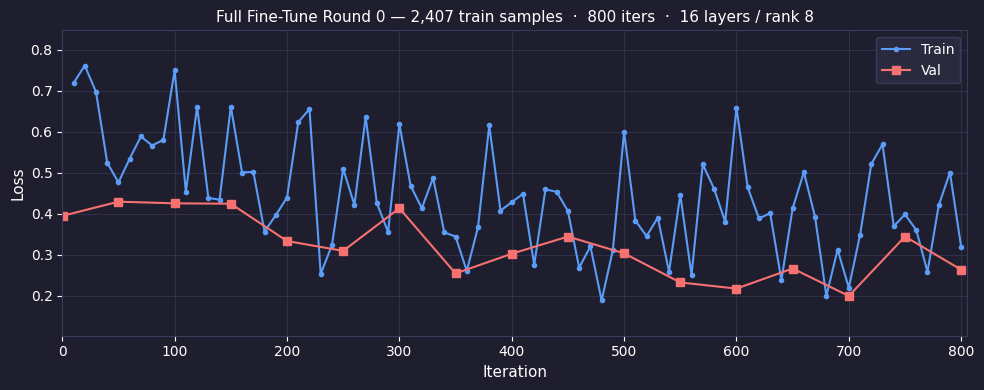

Fine-tuning:   0%|          | 0/800 [00:01<?, ?iter/s]

  Loading configuration file /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter/optim_config.yaml
  Loading pretrained model


Fine-tuning:   0%|          | 0/800 [00:01<?, ?iter/s]

  Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 6216.85it/s]


Fine-tuning:   0%|          | 0/800 [00:03<?, ?iter/s]

...

  iter  800/800  │  train_loss 0.3180  │  lr 1.00e-05  │  0.108 it/s  │  36 tok/s  │  258695 tokens  │  mem 81.270 GB  │  ETA 0m00s


Fine-tuning: 100%|██████████| 800/800 [2:11:05<00:00, 12.16s/iter, loss=0.318, it/s=0.108, mem_GB=81.270, ETA=0m00s]

  Iter 800: Saved adapter weights to /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter/adapters.safetensors and /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter/0000800_adapters.safetensors.
  Saved final weights to /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter/adapters.safetensors.


Fine-tuning: 100%|██████████| 800/800 [2:11:07<00:00,  9.83s/iter, loss=0.318, it/s=0.108, mem_GB=81.270, ETA=0m00s]



Training complete. Adapter saved to: /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter
  Final train_loss: 0.3180
  Best   val_loss:  0.1990  (at iter 700)
  Final  val_loss:  0.2630


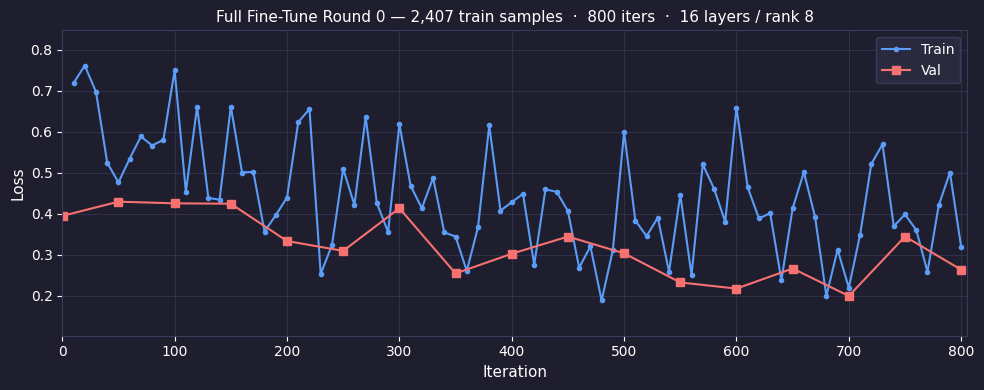

In [5]:
import re
import subprocess
from IPython import get_ipython as _get_ip
_ip = _get_ip()
if _ip:
    _ip.run_line_magic('matplotlib', 'inline')  # initialise backend before pyplot
import matplotlib.pyplot as plt
from IPython import display as ipydisplay
try:
    import ipywidgets as _ipyw
    _ipyw.IntProgress  # raises ImportError if widgets not installed/enabled
    from tqdm.notebook import tqdm as _tqdm_nb
    tqdm = _tqdm_nb
except Exception:
    from tqdm import tqdm
plt.style.use('default')
plt.rcParams.update({
    'text.color': '#222222',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.titlecolor': '#111111',
    'legend.edgecolor': '#cccccc',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#f9f9f9',
})


# ── Optimizer config (weight decay) ──────────────────────────────────────────
# mlx_lm.lora's CLI doesn't expose --weight-decay, so we write a YAML that
# the trainer merges into its defaults. Other CLI args still take precedence.
import yaml
_optim_yaml = ADAPTER_DIR / 'optim_config.yaml'
with open(_optim_yaml, 'w') as f:
    yaml.safe_dump({
        'optimizer': 'adamw',
        'optimizer_config': {'adamw': {'weight_decay': float(WEIGHT_DECAY)}},
    }, f)

train_cmd = [
    sys.executable, '-m', 'mlx_lm', 'lora',
    '--config',                  str(_optim_yaml),
    '--model',                   BASE_MODEL,
    '--data',                    str(DATA_DIR),
    '--train',
    '--batch-size',              str(BATCH_SIZE),
    '--grad-accumulation-steps', str(GRAD_ACCUM),
    '--num-layers',              str(LORA_LAYERS),
    '--learning-rate',           str(LEARNING_RATE),
    '--iters',                   str(ITERS),
    '--save-every',              str(SAVE_EVERY),
    '--steps-per-eval',          str(STEPS_PER_EVAL),
    '--val-batches',             str(VAL_BATCHES),
    '--adapter-path',            str(ADAPTER_DIR),
    '--max-seq-length',          str(MAX_SEQ_LEN),
    '--mask-prompt',
]

# Resume from NB04 warm-start adapter when available so we build on existing
# ARO competence instead of relearning syntax from scratch.
if RESUME_ADAPTER is not None:
    train_cmd += ['--resume-adapter-file', str(RESUME_ADAPTER)]

print('Starting training...')
print(' '.join(train_cmd))
print()

# ── Live loss graph ───────────────────────────────────────────────────────────
train_iters, train_losses = [], []
val_iters,   val_losses   = [], []

_BG   = '#1e1e2e'   # dark background
_FG   = 'white'     # all text / ticks
_GRID = '#3a3a5a'   # subtle grid lines

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(_BG)
ax.set_facecolor(_BG)

ax.set_xlabel('Iteration', color=_FG, fontsize=11)
ax.set_ylabel('Loss',      color=_FG, fontsize=11)
ax.set_title(
    f'Full Fine-Tune Round {ROUND} — {stats["train"]:,} train samples  ·  {ITERS} iters  ·  {LORA_LAYERS} layers / rank {LORA_RANK}',
    color=_FG, fontsize=11,
)
ax.set_xlim(0, ITERS)
ax.set_ylim(0, 3)
ax.tick_params(colors=_FG, labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor(_GRID)
ax.grid(True, color=_GRID, linewidth=0.6, alpha=0.8)

train_line, = ax.plot([], [], color='#5b9cf6', marker='o', ms=3, lw=1.5, label='Train')
val_line,   = ax.plot([], [], color='#f87171', marker='s', ms=6, lw=1.5, label='Val')
leg = ax.legend(facecolor='#2a2a3e', edgecolor=_GRID, labelcolor=_FG, fontsize=10)

plt.tight_layout()
_fig_handle = ipydisplay.display(fig, display_id=True)

def _refresh_plot():
    if train_losses:
        train_line.set_data(train_iters, train_losses)
    if val_losses:
        val_line.set_data(val_iters, val_losses)
    all_y = train_losses + val_losses
    if all_y:
        lo, hi = min(all_y), max(all_y)
        pad = max(0.05, (hi - lo) * 0.15)
        ax.set_ylim(lo - pad, hi + pad)
    all_x = train_iters + val_iters
    if all_x:
        ax.set_xlim(0, max(ITERS, max(all_x)) + 5)
    fig.canvas.draw()
    _fig_handle.update(fig)

_train_re = re.compile(
    r'Iter\s+(\d+):\s+Train loss\s+([-\w.]+)'
    r'(?:.*?Learning Rate\s+([\d.e+-]+))?'
    r'(?:.*?It/sec\s+([\d.]+))?'
    r'(?:.*?Tokens/sec\s+([\d.]+))?'
    r'(?:.*?Trained Tokens\s+([\d,]+))?'
    r'(?:.*?Peak mem\s+([\d.]+)\s*GB)?'
)
_val_re   = re.compile(r'Iter\s+(\d+):\s+Val loss\s+([-\w.]+)(?:.*?Val took\s+([\d.]+)s)?')
_saved_re = re.compile(r'Adapter saved', re.IGNORECASE)

pbar      = tqdm(total=ITERS, desc='Fine-tuning', unit='iter', dynamic_ncols=True)
last_iter = 0

# ── Stability tracking ────────────────────────────────────────────────────────
# Replaced "3 consecutive increases" with "no improvement vs best for N evals":
# the previous logic was reset by any small dip in noisy val loss, so it never
# fired even when val clearly diverged (NB18 run 2026-04-30: val bottomed at iter
# 700 and drifted up through iter 1200 without triggering).
import math
def _is_nan(s):
    try:
        return math.isnan(float(s))
    except (TypeError, ValueError):
        return s.strip().lower() == 'nan'

_best_val_seen     = float('inf')
_no_improve_n      = 0      # evals since last new-best val loss
_stopped_early     = False
_loss_exploded     = False
_loss_nan          = False  # NaN train or val loss observed
_first_train_loss   = None  # first non-NaN train loss (sane band: ~0.5–1.0)
_first_nan_iter     = None  # iter where NaN first appeared
_first_explode_iter = None  # iter where loss > LOSS_EXPLODE_THRESHOLD

proc = subprocess.Popen(
    train_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1,
)
try:
    for raw_line in proc.stdout:
        line = raw_line.rstrip()

        m_train = _train_re.search(line)
        m_val   = _val_re.search(line)

        if m_train:
            it       = int(m_train.group(1))
            loss_str = m_train.group(2)
            if _is_nan(loss_str):
                _loss_nan = True
                if _first_nan_iter is None:
                    _first_nan_iter = it
                tqdm.write(f'\n🚨  NaN train loss at iter {it} — aborting. '
                           f'Likely cause: truncated samples or LR too high.')
                proc.terminate()
                break
            loss        = float(loss_str)
            lr          = m_train.group(3)
            it_sec      = m_train.group(4)
            tok_sec     = m_train.group(5)
            trained_tok = m_train.group(6)
            peak_mem    = m_train.group(7)

            if _first_train_loss is None:
                _first_train_loss = loss
            train_iters.append(it)
            train_losses.append(loss)
            pbar.update(it - last_iter)
            last_iter = it

            # ── Loss explosion guard ──────────────────────────────────────────
            if loss > LOSS_EXPLODE_THRESHOLD:
                _loss_exploded = True
                if _first_explode_iter is None:
                    _first_explode_iter = it
                tqdm.write(f'\n🚨  LOSS EXPLOSION at iter {it}: train_loss={loss:.3f} > {LOSS_EXPLODE_THRESHOLD}')
                tqdm.write('   Killing training process. Try a lower learning rate.')
                proc.terminate()
                break

            eta_str = ''
            if it_sec:
                eta_s = (ITERS - it) / float(it_sec)
                h, r  = divmod(int(eta_s), 3600)
                m_, s = divmod(r, 60)
                eta_str = f'{h}h{m_:02d}m' if h else f'{m_}m{s:02d}s'

            postfix = {'loss': f'{loss:.3f}'}
            if it_sec:   postfix['it/s']   = it_sec
            if peak_mem: postfix['mem_GB'] = peak_mem
            if eta_str:  postfix['ETA']    = eta_str
            pbar.set_postfix(postfix)

            parts = [f'iter {it:>4}/{ITERS}', f'train_loss {loss:.4f}']
            if lr:          parts.append(f'lr {float(lr):.2e}')
            if it_sec:      parts.append(f'{float(it_sec):.3f} it/s')
            if tok_sec:     parts.append(f'{float(tok_sec):.0f} tok/s')
            if trained_tok: parts.append(f'{trained_tok.replace(",","")} tokens')
            if peak_mem:    parts.append(f'mem {peak_mem} GB')
            if eta_str:     parts.append(f'ETA {eta_str}')
            tqdm.write('  ' + '  │  '.join(parts))
            _refresh_plot()

        elif m_val:
            it       = int(m_val.group(1))
            loss_str = m_val.group(2)
            if _is_nan(loss_str):
                _loss_nan = True
                if _first_nan_iter is None:
                    _first_nan_iter = it
                tqdm.write(f'\n🚨  NaN val loss at iter {it} — aborting.')
                proc.terminate()
                break
            loss = float(loss_str)
            val_took = m_val.group(3)

            val_iters.append(it)
            val_losses.append(loss)
            pbar.set_postfix({'loss': f'{train_losses[-1]:.3f}' if train_losses else '?',
                              'val':  f'{loss:.3f}'})
            took_str = f'  ({val_took}s)' if val_took else ''
            tqdm.write(f'  ── val ──  iter {it:>4}/{ITERS}  val_loss {loss:.4f}{took_str}')
            _refresh_plot()

            # ── Early stopping: no improvement vs best for N evals ─────────────
            if loss < _best_val_seen:
                _best_val_seen = loss
                _no_improve_n  = 0
            else:
                _no_improve_n += 1
                tqdm.write(f'  ⚠  no improvement vs best ({_best_val_seen:.4f}) '
                           f'— streak {_no_improve_n}/{NO_IMPROVE_PATIENCE}')
                if _no_improve_n >= NO_IMPROVE_PATIENCE:
                    _stopped_early = True
                    tqdm.write(f'\n⏹  EARLY STOP at iter {it}: val_loss has not beaten '
                               f'best ({_best_val_seen:.4f}) for {NO_IMPROVE_PATIENCE} evals.')
                    proc.terminate()
                    break

        elif _saved_re.search(line):
            tqdm.write(f'  ✓ {line}')
        elif line.strip():
            tqdm.write(f'  {line}')

finally:
    proc.wait()
    pbar.close()

_refresh_plot()

if _loss_nan:
    raise RuntimeError(
        f'Training aborted: NaN loss at iter {_first_nan_iter}. '
        f'Likely cause: truncated samples (check pre-flight log) or LR too high '
        f'(currently {LEARNING_RATE:.0e}). Run the chart cell to see the failure '
        f'banner on the saved PNG.'
    )
if _loss_exploded:
    raise RuntimeError(
        f'Training aborted: loss explosion detected (>{LOSS_EXPLODE_THRESHOLD}) '
        f'at iter {_first_explode_iter}. Reduce LEARNING_RATE '
        f'(currently {LEARNING_RATE:.0e}) and re-run.'
    )
if _stopped_early:
    print(f'\nEarly stopping triggered: val_loss did not beat best for {NO_IMPROVE_PATIENCE} evals.')
    print('Best-checkpoint selection (next cell) will pick the right adapter.')
elif proc.returncode not in (0, -15):  # -15 = SIGTERM (from terminate())
    raise RuntimeError(f'Training failed with exit code {proc.returncode}')

print(f'\nTraining complete. Adapter saved to: {ADAPTER_DIR}')
if train_losses:
    print(f'  Final train_loss: {train_losses[-1]:.4f}')
if val_losses:
    print(f'  Best   val_loss:  {min(val_losses):.4f}  (at iter {val_iters[val_losses.index(min(val_losses))]})')
    print(f'  Final  val_loss:  {val_losses[-1]:.4f}')

## Select best checkpoint

Scan the adapter directory for intermediate checkpoints saved during training.
If validation losses were captured, pick the checkpoint closest to the iteration
with the lowest `val_loss` and copy it to `adapters.safetensors` (the file that
fusing reads). This ensures we fuse from the best model, not just the last one.

In [6]:
import glob, shutil, re as _ckpt_re

# ── Discover checkpoints ──────────────────────────────────────────────────────
# mlx-lm saves intermediate checkpoints as NNNNNNN_adapters.safetensors
# and the final adapter as adapters.safetensors.

_ckpt_pattern = str(ADAPTER_DIR / '*_adapters.safetensors')
_ckpt_files = sorted(glob.glob(_ckpt_pattern))

_final_adapter = ADAPTER_DIR / 'adapters.safetensors'
_has_final = _final_adapter.exists()

print(f'Adapter directory: {ADAPTER_DIR}')
print(f'Checkpoints found: {len(_ckpt_files)}')
for cf in _ckpt_files:
    print(f'  {Path(cf).name}')
if _has_final:
    print(f'  adapters.safetensors (final)')

# ── Best checkpoint selection ─────────────────────────────────────────────────
# If we have val_losses from training, find the iteration with the lowest
# val_loss and pick the closest checkpoint.

_best_ckpt = None
_best_reason = 'no checkpoints available'

if val_losses and _ckpt_files:
    # Find best validation iteration
    _best_val_idx = val_losses.index(min(val_losses))
    _best_val_iter = val_iters[_best_val_idx]
    _best_val_loss = val_losses[_best_val_idx]

    # Parse iteration numbers from checkpoint filenames
    _ckpt_iters = []
    for cf in _ckpt_files:
        m = _ckpt_re.match(r'^(\d+)_adapters\.safetensors$', Path(cf).name)
        if m:
            _ckpt_iters.append((int(m.group(1)), cf))

    if _ckpt_iters:
        # Pick the checkpoint closest to (but not after) the best val iteration
        # If best val iter is at or after the last checkpoint, pick the closest one
        _ckpt_iters.sort(key=lambda x: x[0])

        # Find closest checkpoint to best val iteration
        _closest = min(_ckpt_iters, key=lambda x: abs(x[0] - _best_val_iter))
        _best_ckpt = _closest[1]
        _best_ckpt_iter = _closest[0]
        _best_reason = (f'best val_loss={_best_val_loss:.4f} at iter {_best_val_iter}, '
                        f'closest checkpoint at iter {_best_ckpt_iter}')

        # Check if the final adapter IS the best (i.e., best val was at the last iteration)
        _last_ckpt_iter = _ckpt_iters[-1][0]
        if _has_final and _best_ckpt_iter == _last_ckpt_iter and _best_val_iter >= _last_ckpt_iter:
            # Final adapter is already from the last/best checkpoint — no copy needed
            # unless there's a checkpoint closer to the best val iter
            _final_is_best = abs(ITERS - _best_val_iter) <= abs(_best_ckpt_iter - _best_val_iter)
            if _final_is_best:
                _best_ckpt = None
                _best_reason = (f'final adapter is already the best '
                                f'(best val_loss={_best_val_loss:.4f} at iter {_best_val_iter})')

elif not val_losses and _ckpt_files:
    # No val losses captured — use the last checkpoint (most trained)
    _best_ckpt = _ckpt_files[-1]
    _best_reason = 'no val_loss data available; using last checkpoint'

elif not _ckpt_files and _has_final:
    _best_reason = 'no intermediate checkpoints; using final adapter as-is'

# ── Copy best checkpoint to adapters.safetensors ──────────────────────────────
if _best_ckpt is not None:
    print(f'\nBest checkpoint: {Path(_best_ckpt).name}')
    print(f'  Reason: {_best_reason}')
    print(f'  Copying to adapters.safetensors ...')
    shutil.copy2(_best_ckpt, _final_adapter)
    print(f'  Done. Best checkpoint is now the active adapter.')
else:
    print(f'\nNo checkpoint copy needed: {_best_reason}')

Adapter directory: /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter
Checkpoints found: 12
  0000100_adapters.safetensors
  0000200_adapters.safetensors
  0000300_adapters.safetensors
  0000400_adapters.safetensors
  0000500_adapters.safetensors
  0000600_adapters.safetensors
  0000700_adapters.safetensors
  0000800_adapters.safetensors
  0000900_adapters.safetensors
  0001000_adapters.safetensors
  0001100_adapters.safetensors
  0001200_adapters.safetensors
  adapters.safetensors (final)

Best checkpoint: 0000700_adapters.safetensors
  Reason: best val_loss=0.1990 at iter 700, closest checkpoint at iter 700
  Copying to adapters.safetensors ...
  Done. Best checkpoint is now the active adapter.


## Fuse adapter into base weights

In [7]:
# Fusing creates a standalone model (no adapter needed at inference time).
# This fused model is used as the base for the next iterative round.

fuse_cmd = [
    sys.executable, '-m', 'mlx_lm.fuse',
    '--model',        BASE_MODEL,
    '--adapter-path', str(ADAPTER_DIR),
    '--save-path',    str(FUSED_DIR),
]

print('Fusing adapter into base weights...')
print(' '.join(fuse_cmd))
result = subprocess.run(fuse_cmd)

if result.returncode != 0:
    raise RuntimeError(f'Fuse failed with exit code {result.returncode}')

print(f'Fused model saved to: {FUSED_DIR}')

Fusing adapter into base weights...
/Users/kris/Projects/ARO/ARO-Train/Train/.venv/bin/python -m mlx_lm.fuse --model mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit --adapter-path /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter --save-path /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/fused
Calling `python -m mlx_lm.fuse...` directly is deprecated. Use `mlx_lm.fuse...` or `python -m mlx_lm fuse ...` instead.
Loading pretrained model


Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 4170.12it/s]


Fused model saved to: /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/fused


## Smoke test: generate one sample with fine-tuned model

In [8]:
# Run smoke test as a subprocess so the ~15 GB model is unloaded when it exits.
# Loading in-process would keep the model in RAM for the rest of the notebook.

import textwrap, tempfile

_smoke_script = textwrap.dedent(f"""\
    import sys
    from mlx_lm import load, generate as mlx_generate

    print(f'Loading fused model from {FUSED_DIR} ...')
    model, tokenizer = load(str('{FUSED_DIR}'))

    test_messages = [
        {{'role': 'system',  'content': 'You are an expert ARO language programmer.'}},
        {{'role': 'user',    'content': 'Write an ARO feature set that retrieves a user by id and returns an OK response.'}},
    ]
    prompt = tokenizer.apply_chat_template(test_messages, tokenize=False, add_generation_prompt=True)
    response = mlx_generate(model, tokenizer, prompt=prompt, max_tokens=300, verbose=False)

    print()
    print('=== Smoke test output ===')
    print(response)
""")

with tempfile.NamedTemporaryFile('w', suffix='.py', delete=False) as _tf:
    _tf.write(_smoke_script)
    _smoke_path = _tf.name

_smoke_proc = subprocess.Popen(
    [sys.executable, _smoke_path],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
)
for _line in _smoke_proc.stdout:
    print(_line, end='')
_smoke_proc.wait()

import os
os.unlink(_smoke_path)

if _smoke_proc.returncode != 0:
    print(f'\u26a0  Smoke test exited with code {_smoke_proc.returncode} (non-fatal)')
else:
    print('\u2713  Smoke test passed \u2014 model unloaded (subprocess exited).')


Loading fused model from /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/fused ...

=== Smoke test output ===
```aro
feature GetUserById {
    description "Retrieve a user by their unique identifier"
    
    scenario "Retrieve existing user by ID" {
        given the user service is available
        and a valid user ID exists in the system
        when the get user endpoint is called with valid ID
        then the system returns a successful response with user data
        and the response status code is 200 OK
    }
    
    scenario "User not found" {
        given a non-existent user ID
        when the get user endpoint is called with invalid ID
        then the system returns a 404 Not Found response
    }
    
    scenario "Invalid ID format" {
        given an invalid ID format (e.g. non-numeric for numeric ID)
        when the get user endpoint is called with invalid format
        then the system returns a 400 Bad Request response
    }
}
```
✓  Smoke test p

## Save round metadata

In [9]:
meta = {
    'round':           ROUND,
    'base_model':      BASE_MODEL,
    'resumed_from':    str(RESUME_ADAPTER) if RESUME_ADAPTER else None,
    'adapter_dir':     str(ADAPTER_DIR),
    'fused_dir':       str(FUSED_DIR),
    'train_samples':   stats['train'],
    'iters':           ITERS,
    'batch_size':      BATCH_SIZE,
    'grad_accum':      GRAD_ACCUM,
    'effective_batch': BATCH_SIZE * GRAD_ACCUM,
    'lora_layers':     LORA_LAYERS,
    'lora_rank':       LORA_RANK,
    'learning_rate':   LEARNING_RATE,
    'weight_decay':    WEIGHT_DECAY,
    'steps_per_eval':  STEPS_PER_EVAL,
    'no_improve_patience': NO_IMPROVE_PATIENCE,
    'max_seq_len':     MAX_SEQ_LEN,
    'stopped_early':   bool(_stopped_early),
}
_meta_dir = FINETUNE_MODELS_DIR / f'round_{ROUND}'
_meta_dir.mkdir(parents=True, exist_ok=True)
with open(_meta_dir / 'meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'\nRound {ROUND} complete.')
print(f'  Next step: run notebook 19 for iterative self-improvement rounds,')
print(f'             or notebook 20 for evaluation.')


Round 0 complete.
  Next step: run notebook 19 for iterative self-improvement rounds,
             or notebook 20 for evaluation.


In [10]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams.update({
    'text.color': '#222222',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.titlecolor': '#111111',
    'legend.edgecolor': '#cccccc',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#f9f9f9',
    'savefig.facecolor': '#fafafa',
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})
from pathlib import Path
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '17_finetune.png'

# Prefer data captured live during training; fall back to adapter log file.
_tl, _vl = train_losses, val_losses
_ti, _vi = train_iters,  val_iters

if not _tl:
    import json as _json
    _train_log = ADAPTER_DIR / 'training_log.jsonl'
    if _train_log.exists():
        with open(_train_log) as _f:
            for _line in _f:
                try:
                    _e = _json.loads(_line)
                    if 'train_loss' in _e:
                        _ti.append(_e['iteration']); _tl.append(_e['train_loss'])
                    if 'val_loss' in _e:
                        _vi.append(_e['iteration']); _vl.append(_e['val_loss'])
                except Exception:
                    pass

fig2, ax2 = plt.subplots(figsize=(10, 5))

if _tl:
    ax2.plot(_ti, _tl, 'b-o', ms=3, lw=1.5, label='Train loss')
    if _vl:
        ax2.plot(_vi, _vl, 'r-s', ms=7, lw=1.5, label='Val loss')
        ax2.axhline(min(_vl), color='r', lw=0.8, ls='--', alpha=0.5,
                    label=f'Best val {min(_vl):.4f}')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Loss')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)
else:
    _task_counts = stats.get('task_counts', {})
    if _task_counts:
        _tc_labels = list(_task_counts.keys())
        _tc_values = list(_task_counts.values())
        ax2.bar(_tc_labels, _tc_values, color='#3498db', edgecolor='white', width=0.6)
        ax2.set_xticklabels([t.replace('_', '\n') for t in _tc_labels], fontsize=9)
        ax2.set_ylabel('Samples')
        ax2.grid(axis='y', alpha=0.3)
        ax2.text(0.5, 0.92, 'Training log not available yet — showing dataset composition',
                 transform=ax2.transAxes, ha='center', fontsize=9, color='#888')

ax2.set_title(
    f'Full Fine-Tune — Round {ROUND}  ·  {stats["train"]:,} train samples  ·  {ITERS} iters  ·  {LORA_LAYERS} layers / rank {LORA_RANK}',
    fontsize=13, fontweight='bold',
)

# ── Warning overlay (matches NB19) ─────────────────────────────────
# Triggers when the training run was unhealthy: NaN, an explosion, or
# a starting train loss outside the sane 0.5–2.0 band. Renders a big
# coloured banner on the PNG so the failure is impossible to miss.
_warning_msg = None
_warning_color = '#c0392b'   # red
if globals().get('_loss_nan'):
    _at = f'iter {_first_nan_iter}' if globals().get('_first_nan_iter') is not None else 'early'
    _warning_msg = (
        f'TRAINING FAILED — NaN train loss at {_at}\n'
        f'Expected sane train loss ~0.5–1.0\n'
        f'Adapter is unusable. Lower LR (now {LEARNING_RATE:.0e}) '
        f'or tighten MAX_SEQ_LEN.'
    )
elif globals().get('_loss_exploded'):
    _at = f'iter {_first_explode_iter}' if globals().get('_first_explode_iter') is not None else 'early'
    _warning_msg = (
        f'TRAINING FAILED — loss explosion at {_at} '
        f'(>{LOSS_EXPLODE_THRESHOLD})\n'
        f'Reduce LEARNING_RATE (now {LEARNING_RATE:.0e}).'
    )
elif globals().get('_first_train_loss') is not None and _first_train_loss > 2.0:
    _warning_color = '#e67e22'   # orange — suspicious but not fatal
    _warning_msg = (
        f'WARNING — first train loss {_first_train_loss:.2f} '
        f'(expected ~0.5–1.0)\n'
        f'Possible LR / data mismatch. Inspect the loss curve.'
    )
elif globals().get('_first_train_loss') is not None and _first_train_loss < 0.05:
    _warning_color = '#e67e22'
    _warning_msg = (
        f'WARNING — first train loss {_first_train_loss:.4f} is suspiciously low\n'
        f'Likely the training data is too easy or already memorized.'
    )

if _warning_msg:
    fig2.text(
        0.5, 0.5, _warning_msg,
        ha='center', va='center',
        fontsize=15, fontweight='bold', color='white',
        bbox=dict(facecolor=_warning_color, alpha=0.95,
                  boxstyle='round,pad=1.0', edgecolor='black', linewidth=1.5),
        zorder=100,
    )

fig2.tight_layout()
fig2.savefig(_out)
plt.close(fig2)
print(f'Saved: {_out}')

Saved: run/2026-05-03/17_finetune.png


In [11]:
import csv
from pathlib import Path
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)

with open(_run_dir / '17_finetune.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['iteration', 'train_loss', 'val_loss'])
    # Build a lookup of val losses by iteration
    _val_by_iter = dict(zip(val_iters, val_losses))
    # Write one row per logged training iteration
    for it, tl in zip(train_iters, train_losses):
        vl = _val_by_iter.get(it, '')
        w.writerow([it, f'{tl:.4f}', f'{vl:.4f}' if vl != '' else ''])

print(f'Saved: {_run_dir / "17_finetune.csv"}')

Saved: run/2026-05-03/17_finetune.csv


## Summary

In [12]:
print('=' * 65)
print('notebook 18 — FULL FINE-TUNE SUMMARY')
print('=' * 65)

print(f'\nConfiguration:')
print(f'  Base model:        {BASE_MODEL}')
print(f'  Resumed from:      {RESUME_ADAPTER if RESUME_ADAPTER else "(none — base model)"}')
print(f'  Learning rate:     {LEARNING_RATE:.0e}')
print(f'  Weight decay:      {WEIGHT_DECAY}')
print(f'  LoRA layers/rank:  {LORA_LAYERS} / {LORA_RANK}')
print(f'  Effective batch:   {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM}')
print(f'  Iterations:        {ITERS}')
print(f'  Eval every:        {STEPS_PER_EVAL} iters')
print(f'  Patience:          {NO_IMPROVE_PATIENCE} evals without new best')
print(f'  Max seq length:    {MAX_SEQ_LEN}')

print(f'\nTraining outcome:')
if train_losses:
    _initial = train_losses[0]
    _final   = train_losses[-1]
    _best_t  = min(train_losses)
    print(f'  Train loss:  {_initial:.4f} → {_final:.4f}  (best {_best_t:.4f})')
    if _final > _initial * 1.5:
        print('  ⚠  Train loss is HIGHER than initial — likely diverged.')
    elif _final > 2.5:
        print('  ⚠  Train loss still high (>2.5) — may need more iterations or lower LR.')
    else:
        print('  ✓  Train loss decreased normally.')
else:
    print('  (no training loss data available)')

if val_losses:
    _best_v  = min(val_losses)
    _best_vi = val_iters[val_losses.index(_best_v)]
    _final_v = val_losses[-1]
    print(f'  Val   loss:  first {val_losses[0]:.4f} → best {_best_v:.4f} @ iter {_best_vi} → final {_final_v:.4f}')
    if _final_v > val_losses[0]:
        print('  ⚠  Val loss is HIGHER than initial val loss — model diverged (overfitting/instability).')
    else:
        print('  ✓  Val loss improved from start.')
else:
    print('  (no validation loss data available)')

print(f'\nStability:')
if _loss_exploded:
    print(f'  🚨  Loss explosion occurred — training was aborted.')
    print(f'      Next step: reduce LEARNING_RATE to {LEARNING_RATE/2:.0e} and re-run.')
elif _stopped_early:
    print(f'  ⏹  Early stopping triggered (no val improvement for {NO_IMPROVE_PATIENCE} evals).')
    print(f'      Best checkpoint is at iter {val_iters[val_losses.index(min(val_losses))]}.')
else:
    print(f'  ✓  Training ran to completion ({ITERS} iters).')

print(f'\nOutputs:')
print(f'  Adapter:     {ADAPTER_DIR}')
print(f'  Fused model: {FUSED_DIR}')
print(f'  Meta:        {FINETUNE_MODELS_DIR / f"round_{ROUND}" / "meta.json"}')

print(f'\nNext steps:')
print(f'  1. Run NB20 (evaluation) to measure model quality.')
print(f'  2. If smoke test still produces garbage, re-run NB18 with lower LR.')
print(f'  3. If val_loss > train_loss by >1.0, dataset may be too small — run NB10 again.')
print('=' * 65)

notebook 18 — FULL FINE-TUNE SUMMARY

Configuration:
  Base model:        mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
  Resumed from:      /Users/kris/Projects/ARO/ARO-Train/Train/data/adapters/warm_start/adapters.safetensors
  Learning rate:     1e-05
  Weight decay:      0.01
  LoRA layers/rank:  16 / 8
  Effective batch:   2 × 8 = 16
  Iterations:        800
  Eval every:        50 iters
  Patience:          4 evals without new best
  Max seq length:    4096

Training outcome:
  Train loss:  0.7180 → 0.3180  (best 0.1880)
  ✓  Train loss decreased normally.
  Val   loss:  first 0.3950 → best 0.1990 @ iter 700 → final 0.2630
  ✓  Val loss improved from start.

Stability:
  ✓  Training ran to completion (800 iters).

Outputs:
  Adapter:     /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter
  Fused model: /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/fused
  Meta:        /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/meta.